# Coarse Gain Change
Coarse gain change is a instantaneous change in the amplitude level. It is intended to simulate an immediate change in transmit or receiver gain. Because TorchSig does not fully simulate receiver effects, reducing the gain will reduce the noise and the signal by the same factor; increasing the gain will increase the noise and the signal by the same factor as well.

In [1]:
from torchsig.signals.signal_types import Signal
from torchsig.utils.defaults import default_dataset
import torchsig.transforms.functional as F

import numpy as np

#%matplotlib inline
import matplotlib.pyplot as plt

An example signal is created to test the gain change transform.

In [2]:
def generate_qpsk_signal(num_iq_samples: int = 128, scale: float = 1.0) -> Signal:
    """Generate a scaled, high SNR baseband QPSK Signal.

    Args:
    num_iq_samples (int, optional): Length of sample. Defaults to 128.
    scale (float, optional): scale normalized signal data. Defaults to 1.0.

    Returns:
        signal: generated Signal.

    """
    dataset = default_dataset(
        signal_generators=["qpsk"],
        num_signals_min=1,
        num_signals_max=1,
        signal_duration_in_samples_min=num_iq_samples,
        signal_duration_in_samples_max=num_iq_samples,
        noise_power_db=0.0,
        start_in_samples=0,
        seed=42,
    )
    signal = dataset.signal_generators[0]()

    # normalize, then scale data
    signal.data = F.normalize(data=signal.data, norm_order=2, flatten=False)
    signal.data = signal.data * scale

    return signal

Notice how the gain change applies an immediate increase in the gain to the QPSK signal.

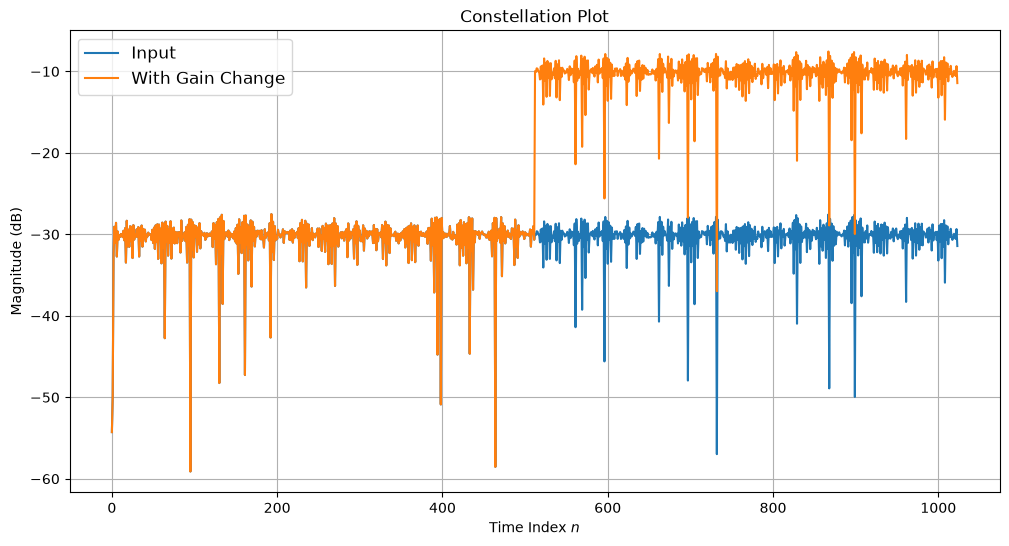

In [3]:
# test data
N = 1024
qpsk_data = generate_qpsk_signal(num_iq_samples=N, scale=1.0).data

# add in a tiny amount of noise to avoid log10(0)
complex_noise = np.sqrt(1e-6) * (
    np.random.normal(0, 1, N) + 1j * np.random.normal(0, 1, N)
)
qpsk_data += complex_noise

impaired_qpsk_data = F.coarse_gain_change(
    data=qpsk_data, gain_change_db=20, start_idx=N // 2
)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(20 * np.log10(np.abs(qpsk_data)), label="Input")
ax.plot(20 * np.log10(np.abs(impaired_qpsk_data)), label="With Gain Change")
ax.grid()
ax.set_title("Constellation Plot")
ax.set_xlabel("Time Index $n$")
ax.set_ylabel("Magnitude (dB)")
ax.legend(fontsize="large", loc="upper left");